# Data cleaning and analysis

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path = Path("..") / "data" / "raw" / f"training_pop30_genres.parquet"
data_path = Path.home() / "Dropbox/Progetti/ml/data/training_pop50_genres.parquet"
df = pd.read_parquet(data_path)
print(f"Loaded {len(df):,} tracks from {data_path}")

Loaded 186,960 tracks from /Users/peppedilillo/Dropbox/Progetti/ml/data/training_pop50_genres.parquet


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186960 entries, 0 to 186959
Data columns (total 34 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   track_rowid             186960 non-null  int64  
 1   track_name              186960 non-null  object 
 2   artist_name             186960 non-null  object 
 3   artist_rowid            186960 non-null  int64  
 4   album_rowid             186960 non-null  int64  
 5   album_name              186960 non-null  object 
 6   album_type              186960 non-null  object 
 7   label                   186960 non-null  object 
 8   release_date            186960 non-null  object 
 9   release_date_precision  186960 non-null  object 
 10  id_isrc                 186947 non-null  object 
 11  id_upc                  186297 non-null  object 
 12  time_signature          186960 non-null  int64  
 13  tempo                   186960 non-null  float64
 14  key                 

In [4]:
missing = df.isna().sum()
100 * missing[missing > 0] / len(df)

id_isrc           0.006953
id_upc            0.354621
artist_genres    29.322315
dtype: float64

In [5]:
missing = df.isna().sum()
missing[missing > 0]

id_isrc             13
id_upc             663
artist_genres    54821
dtype: int64

In [6]:
# df = df.dropna(subset=("id_isrc", "id_upc"))

## Album Type

In [7]:
df["album_type"].describe()

count     186960
unique         3
top        album
freq      105137
Name: album_type, dtype: object

In [8]:
df["album_type"].value_counts()

album_type
album          105137
single          76404
compilation      5419
Name: count, dtype: int64

Sets album type to categorical.

In [9]:
df["album_type"] = df["album_type"].astype("category")

## Dates

In [10]:
release_date = pd.to_datetime(df["release_date"], format="mixed", errors="coerce")

Drops entries with bad release date format.

In [11]:
print(f"there are {release_date.isna().sum()} tracks with bad release date format.")
df[release_date.isna()].head()

there are 1 tracks with bad release date format.


,track_rowid,track_name,artist_name,artist_rowid,album_rowid,album_name,album_type,label,release_date,release_date_precision,...,explicit,track_popularity,artist_popularity,artist_followers,album_popularity,duration_ms,track_number,disc_number,total_tracks,artist_genres
102516,148604550,青いベンチ,Sasuke,2037010,32296293,Smile,album,MoMoMo Records.,0000,year,...,0,56,43,21569,44,242066,6,1,7,j-pop


In [12]:
drop = release_date.isna()

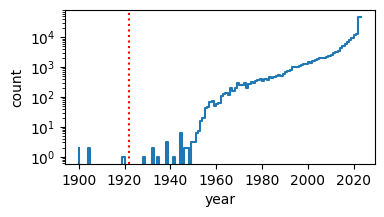

In [13]:
counts, bins = np.histogram(
    _r := release_date[~drop].dt.year, 
    bins=np.arange(_r.min(), _r.max(), 1)
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts)
plt.axvline(1922, linestyle="dotted", c="red")
plt.semilogy(); plt.xlabel("year"); plt.ylabel("count")
plt.show()

Drops entries before 1922.

In [14]:
drop = drop | (release_date.dt.year < 1922)

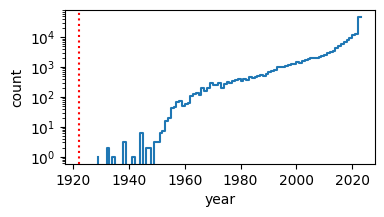

In [15]:
counts, bins = np.histogram(
    _r := release_date[~drop].dt.year, 
    bins=np.arange(_r.min(), _r.max(), 1)
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts)
plt.axvline(1922, linestyle="dotted", c="red")
plt.semilogy(); plt.xlabel("year"); plt.ylabel("count")
plt.show()

In [16]:
print(f"dropping {(_n := drop.sum())} rows ({_n / len(df):.3f} %))")

dropping 6 rows (0.000 %))


In [17]:
df = df[~drop].reset_index(drop=True)

Replace `release_date` and `release_date_precision` with `release_year` and `release_season` columns

In [18]:
def extract_release_features(df: pd.DataFrame) -> pd.DataFrame:
    """Extract release_year and release_season from release_date strings."""
    dt = pd.to_datetime(df["release_date"], format="mixed")
    
    year = dt.dt.year
    month = dt.dt.month
    
    season_map = {
        12: 'winter', 1: 'winter', 2: 'winter',
        3: 'spring', 4: 'spring', 5: 'spring',
        6: 'summer', 7: 'summer', 8: 'summer',
        9: 'fall', 10: 'fall', 11: 'fall'
    }
    season = month.map(season_map).fillna('unknown').astype('category')
    
    return pd.DataFrame({
        'release_year': year,
        'release_season': season
    })

_df = extract_release_features(df)
idx = df.columns.get_loc('release_date_precision')
df.insert(idx + 1, '_release_year', _df["release_year"])
df.insert(idx + 2, '_release_season', _df["release_season"])

## Artist 

Annotates years passed from first artist release.

In [19]:
idx = df.columns.get_loc('_release_season')
df.insert(
    idx + 1, 
    "_release_years_since_first_artist_release", 
    (df["_release_year"] - df.groupby("artist_rowid")["_release_year"].transform("min"))
)

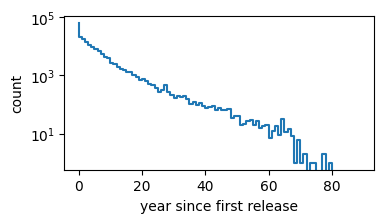

In [20]:
counts, bins = np.histogram(
    _r := df["_release_years_since_first_artist_release"], 
    bins=np.arange(_r.min(), _r.max(), 1)
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts)
plt.semilogy(); plt.xlabel("year since first release"); plt.ylabel("count")
plt.show()

## Label

In [21]:
def extract_label_album_count(df: pd.DataFrame) -> pd.Series:
    """Extract cumulative album count per label at time of release."""
    albums = df[['label', 'album_rowid', '_release_year']].drop_duplicates(subset='album_rowid')
    albums = albums.sort_values(['label', '_release_year', 'album_rowid'])
    albums['count'] = albums.groupby('label').cumcount() + 1
    return df['album_rowid'].map(albums.set_index('album_rowid')['count'])

idx = df.columns.get_loc('label')
df.insert(idx + 1, '_label_album_count', extract_label_album_count(df))

In [23]:
df[df["label"] == "Warp Records"].sort_values("_release_year")[["album_name", "label", "release_date", "_label_album_count"]]

,album_name,label,release_date,_label_album_count
93034,Selected Ambient Works Volume II,Warp Records,1994-03-07,1
157757,Selected Ambient Works Volume II,Warp Records,1994-03-07,1
115756,...I Care Because You Do,Warp Records,1995-04-24,2
63175,Richard D. James Album,Warp Records,1996-11-04,3
79166,Come To Daddy,Warp Records,1997-10-06,4
140752,Come To Daddy,Warp Records,1997-10-06,4
105065,Music Has The Right To Children,Warp Records,1998-04-20,5
105066,Music Has The Right To Children,Warp Records,1998-04-20,5
2624,Music Has The Right To Children,Warp Records,1998-04-20,5
61711,Carboot Soul,Warp Records,1999-04-12,6


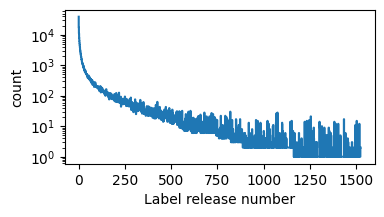

In [24]:
counts, bins = np.histogram(
    _r := df["_label_album_count"], 
    bins=np.arange(_r.min(), _r.max(), 1)
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts)
plt.semilogy(); plt.xlabel("Label release number"); plt.ylabel("count")
plt.show()

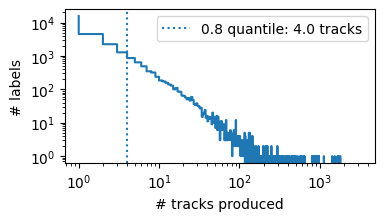

In [25]:
counts, bins = np.histogram(
    _l := df["label"].value_counts(), 
    bins=np.arange(_l.min(), _l.max(), 1)
)

plt.figure(figsize=(4,2))
plt.step(bins[:-1], counts)
plt.axvline(_lq := _l.quantile(0.80), linestyle="dotted", label=f"0.8 quantile: {_lq} tracks")
plt.loglog(); plt.xlabel("# tracks produced"); plt.ylabel("# labels"); plt.legend()
plt.show()

In [26]:
_l = df["label"].value_counts()
for n in range(1, 6):
    q = 1.0 - 0.2 ** n
    _lm = _l > _l.quantile(q)
    _ln = _lm.sum()
    _ltn = _l[_lm].sum()
    print(f"the top {100 * (1 - q):.2f}% labels ({_ln} out of {len(_l)}) produced {_ltn} tracks, or {100 * _ltn / len(df):.2f}% of the dataset.")

the top 20.00% labels (5468 out of 29055) produced 150516 tracks, or 80.51% of the dataset.
the top 4.00% labels (1117 out of 29055) produced 107901 tracks, or 57.72% of the dataset.
the top 0.80% labels (232 out of 29055) produced 68472 tracks, or 36.63% of the dataset.
the top 0.16% labels (47 out of 29055) produced 36353 tracks, or 19.44% of the dataset.
the top 0.03% labels (10 out of 29055) produced 15443 tracks, or 8.26% of the dataset.


In [28]:
_l = df["label"].value_counts()
for label in [
    "Stones Throw Records",
    "Merge Records",
    "Sub Pop Records",
    "Dischord Records",
    "SST Records",
]:
    _ln = _l.loc[label]
    print(f"label {label} produced {_ln} tracks. top {100 * (_l >= _ln).sum() / len(_l):.3f} %")

label Stones Throw Records produced 39 tracks. top 2.275 %
label Merge Records produced 23 tracks. top 4.206 %
label Sub Pop Records produced 132 tracks. top 0.578 %
label Dischord Records produced 7 tracks. top 13.633 %
label SST Records produced 2 tracks. top 46.508 %


Censors small label names to keep label embedding at size.

In [22]:
def map_categorical_by_frequency(s: pd.Series, n: int, labels: list[str], qsplit: float=0.2) -> pd.Series:
    """
    Map a categorical series based on value frequency quantiles.
    """
    if len(labels) != n:
        raise ValueError(f"labels must have exactly {n} elements, got {len(labels)}")
    
    counts = s.value_counts()
    thresholds = [counts.quantile(1.0 - qsplit ** i) for i in range(1, n + 1)]
    
    mapping = {}
    for val, cnt in counts.items():
        mapped_val = val
        for i, thresh in enumerate(thresholds):
            if cnt < thresh:
                mapped_val = labels[i]
                break
        mapping[val] = mapped_val
    
    return s.map(mapping)


idx = df.columns.get_loc('label')
df.insert(idx + 1, '_label', map_categorical_by_frequency(df["label"], 2, ["<XS_LABEL>", "<S_LABEL>"]).astype("category"))

In [23]:
df.columns

Index(['track_rowid', 'track_name', 'artist_name', 'artist_rowid',
       'album_rowid', 'album_name', 'album_type', 'label', '_label',
       'release_date', 'release_date_precision', '_release_year',
       '_release_season', 'id_isrc', 'id_upc', 'time_signature', 'tempo',
       'key', 'mode', 'danceability', 'energy', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'explicit',
       'track_popularity', 'artist_popularity', 'artist_followers',
       'album_popularity', 'duration_ms', 'track_number', 'disc_number',
       'total_tracks', 'artist_genres'],
      dtype='object')